# 07 — Typing Structure and Editing Behaviour

## What this covers that notebook 04 did not

Notebook 04 treated typing as a **timing** stream — press-to-press intervals, key rate.
That is a small part of what the keyboard logs. This notebook uses the rest:

| field | what it reveals |
|---|---|
| `payload_keyClass` | a 7-way privacy-safe class for every keystroke (LETTER, SPACE, BACKSPACE, DIGIT, ENTER, PUNCT_OR_SYMBOL, OTHER) |
| `payload_repeat` | whether a key was **held** rather than pressed — holding backspace to wipe a field is a strategy |
| `payload_selectionStart` / `valueLength` | caret position — did they navigate into the text to fix an error, or delete back to it? |
| `beforeinput.inputType` | insert, delete, replacement, paste |

**Dwell time is deliberately absent.** Notebook 04 established it is a platform constant on
a touchscreen (~10 ms for nearly everyone). Nothing here revisits it.

## The privacy story, which is the interesting part

P1 used literal digraph timings — the interval for `th`, `he`, `in`, `er` — which required
retaining what was typed. P2 cannot do that and should not want to.

The **class transition** is the privacy-preserving substitute. The time from a LETTER to the
next LETTER carries the same kind of motor information as a specific letter pair, without
the content ever leaving the device. Section 4 asks whether that substitution actually
costs anything.

## Why correction behaviour is the promising seam

Backspace share runs from under 1% to over 17% across this cohort — a factor of twenty,
wider than any timing feature measured anywhere in this project. Correcting is also
cognitively different from typing: it requires noticing an error, deciding to fix it, and
choosing *how*. Sections 6 to 8 take that apart.

## The constraint that shapes everything below

Typing is afforded by only four of fifteen task types, so there is far less of it than
tapping or scrolling. One participant produced **19 keystrokes in total**. Section 2 makes
that concrete before any statistic is computed, and every later figure names who cannot be
measured rather than silently dropping them.

## What this notebook does not do

No scoring, no ranking, no verdict. Where the original computed a separability number, this
version plots the distribution that number was summarising.

## Sections

1. Setup
2. How much typing is there, really?
3. Keystroke composition
4. Key-class transitions — the digraph substitute
5. Transition timing — what the substitute actually measures
6. Correction: how much, and in what shape
7. Hold or tap — two ways to delete
8. Caret repositioning — navigating versus deleting back
9. Does the task confound the editing features?
10. The fix: normalise by text, condition on task
11. Predictive text, found by accident
12. Typing bursts — rhythm above the keystroke
13. Does any of this hold within a person?
14. Data-quality notes and rejected derivations
15. Per-participant cards
16. Open questions

## 1. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pd.set_option('display.max_columns', 60); pd.set_option('display.width', 210)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.22,
                     'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9})

_CANDIDATES = ["../../data/processed/raw_events.parquet",
               "data/processed/raw_events.parquet",
               "raw_events.parquet",
               "/mnt/user-data/uploads/raw_events.parquet"]
_src = next((p for p in _CANDIDATES if Path(p).exists()), None)
if _src is None:
    raise FileNotFoundError(f"no raw events file found; tried {_CANDIDATES}")
raw_all = pd.read_parquet(_src)
raw_all['deviceFamily'] = raw_all['deviceFamily'].astype(str).str.lower()
raw_all['tRelMs'] = pd.to_numeric(raw_all['tRelMs'], errors='coerce')
raw_all = raw_all.loc[raw_all['tRelMs'].notna()].copy()
raw = raw_all.loc[raw_all['deviceFamily'] == 'mobile'].copy()

KEY_DOWN, BEFORE_INPUT = 'keydown', 'beforeinput'
KEY_CLASSES = ['LETTER', 'SPACE', 'BACKSPACE', 'DIGIT', 'PUNCT_OR_SYMBOL', 'ENTER', 'OTHER']
MIN_EVENTS_FOR_STAT = 20      # below this, report the number but do not read it as a trait

session_index = (raw.groupby(['participantId', 'sessionId'], dropna=False)
                 .agg(duration_s=('tRelMs', lambda s: s.max() / 1000.0),
                      started=('timestampIso', 'min')).reset_index())
session_index['session_start'] = pd.to_datetime(session_index['started'], utc=True, errors='coerce')
session_index = session_index.sort_values(['participantId', 'session_start']).reset_index(drop=True)
session_index['session_no'] = session_index.groupby('participantId').cumcount() + 1
SESSION_LABEL = {r.sessionId: f"{r.participantId} s{r.session_no}" for r in session_index.itertuples()}
SESSION_ORDER = session_index.sort_values(['participantId', 'session_no'])['sessionId'].tolist()

keys = raw.loc[raw['kind'] == KEY_DOWN].sort_values(['sessionId', 'tRelMs']).copy()
keys['keyClass'] = keys['payload_keyClass'].astype(str)

_vol = keys.groupby('participantId').size().sort_values(ascending=False)
PARTICIPANTS = _vol.index.astype(str).tolist()
_QUAL = plt.get_cmap('tab10')
PCOL = {p: _QUAL(i % 10) for i, p in enumerate(PARTICIPANTS)}
def pcolor(p): return PCOL.get(str(p), '0.5')

print(f"Loaded {_src}")
print(f"{len(keys):,} keystrokes across {keys['sessionId'].nunique()} sessions, "
      f"{len(PARTICIPANTS)} participants")
print(f"\nkeystrokes per participant (this ordering is used throughout):")
for p in PARTICIPANTS:
    print(f"  {p}  {_vol[p]:5,}")

Loaded ../../data/processed/raw_events.parquet
3,070 keystrokes across 29 sessions, 10 participants

keystrokes per participant (this ordering is used throughout):
  pH3S4X4    930
  pG5G4MS    691
  p3YDMHG    513
  pA6XL23    283
  pZMC82M    182
  p3M6E7Z    165
  pAFQRTM    126
  p95MPVX    119
  pWS9VTN     42
  pUNKH7L     19


## 2. How much typing is there, really?

Every claim in this notebook is bounded by this table. Typing is afforded by only four of
fifteen task types, so there is far less of it than tapping or scrolling — and it is
distributed very unevenly across the cohort.

The rule applied throughout: **report the count next to every statistic, and refuse to read
anything below `MIN_EVENTS_FOR_STAT` as a trait** rather than producing a confident-looking
number from a handful of observations.

participant  sessions  keystrokes  per_session  letters  backspaces
    pH3S4X4         8         930        116.2      714          22
    pG5G4MS         6         691        115.2      552           6
    p3YDMHG         4         513        128.2      376          30
    pA6XL23         2         283        141.5      203          19
    pZMC82M         1         182        182.0      111          32
    p3M6E7Z         1         165        165.0      115          18
    pAFQRTM         1         126        126.0       89           9
    p95MPVX         4         119         29.8       71          20
    pWS9VTN         1          42         42.0       24           8
    pUNKH7L         1          19         19.0       10           3

Under 100 keystrokes in total: pWS9VTN, pUNKH7L
Nothing in this notebook should be read as a trait for these participants.


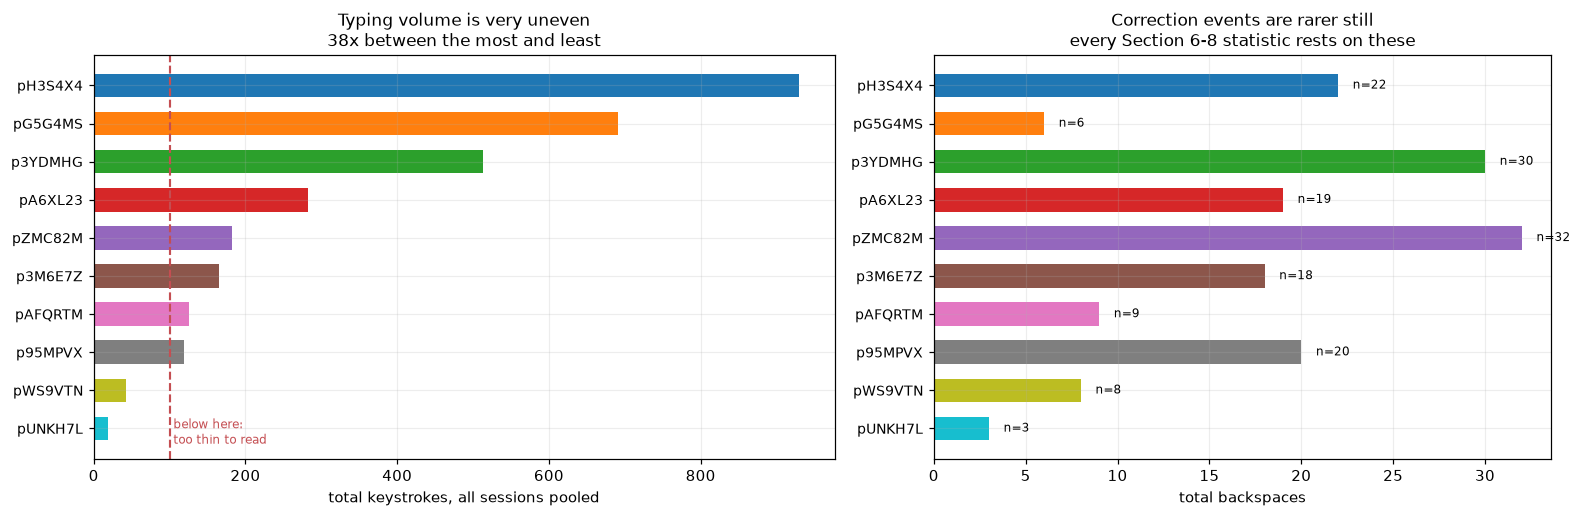

In [2]:
vol_rows = []
for p in PARTICIPANTS:
    k = keys.loc[keys['participantId'] == p]
    n_sess = (session_index['participantId'] == p).sum()
    vol_rows.append({'participant': p, 'sessions': int(n_sess), 'keystrokes': len(k),
                     'per_session': round(len(k) / max(n_sess, 1), 1),
                     'letters': int((k['keyClass'] == 'LETTER').sum()),
                     'backspaces': int((k['keyClass'] == 'BACKSPACE').sum())})
volume = pd.DataFrame(vol_rows)
print(volume.to_string(index=False))
_thin = volume.loc[volume['keystrokes'] < 100, 'participant'].tolist()
if _thin:
    print(f"\nUnder 100 keystrokes in total: {', '.join(_thin)}")
    print("Nothing in this notebook should be read as a trait for these participants.")


def plot_volume(volume):
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8), gridspec_kw={'width_ratios': [1.2, 1]})
    ax = axes[0]
    y = np.arange(len(volume))
    ax.barh(y, volume['keystrokes'], color=[pcolor(p) for p in volume['participant']], height=0.62)
    ax.axvline(100, color='#c44e52', ls='--', lw=1.4)
    ax.text(105, len(volume) - 0.6, "below here:\ntoo thin to read", fontsize=8, color='#c44e52')
    ax.set_yticks(y); ax.set_yticklabels(volume['participant'], fontsize=9); ax.invert_yaxis()
    ax.set_xlabel("total keystrokes, all sessions pooled")
    ax.set_title("Typing volume is very uneven\n38x between the most and least")

    ax = axes[1]
    ax.barh(y, volume['backspaces'], color=[pcolor(p) for p in volume['participant']], height=0.62)
    for i, r in volume.iterrows():
        ax.text(r['backspaces'] + 0.8, i, f"n={r['backspaces']}", va='center', fontsize=8)
    ax.set_yticks(y); ax.set_yticklabels(volume['participant'], fontsize=9); ax.invert_yaxis()
    ax.set_xlabel("total backspaces")
    ax.set_title("Correction events are rarer still\nevery Section 6-8 statistic rests on these")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_volume(volume)

## 3. Keystroke composition

The simplest possible feature, and one of the most separating: what fraction of a person's
keystrokes are letters, spaces, backspaces.

**Backspace share is the one to watch.** It is a direct measure of how much of someone's
typing is spent undoing typing — and it has the widest spread of anything in this project.

Share of each keystroke class:

keyClass       LETTER  SPACE  BACKSPACE  DIGIT  PUNCT_OR_SYMBOL  ENTER  OTHER
participantId                                                                
pH3S4X4         0.768  0.105      0.024  0.027            0.034  0.003  0.039
pG5G4MS         0.799  0.109      0.009  0.026            0.036  0.000  0.022
p3YDMHG         0.733  0.105      0.058  0.029            0.033  0.000  0.041
pA6XL23         0.717  0.138      0.067  0.021            0.014  0.011  0.032
pZMC82M         0.610  0.082      0.176  0.049            0.027  0.011  0.044
p3M6E7Z         0.697  0.103      0.109  0.036            0.042  0.006  0.006
pAFQRTM         0.706  0.079      0.071  0.016            0.024  0.024  0.079
p95MPVX         0.597  0.025      0.168  0.101            0.017  0.008  0.084
pWS9VTN         0.571  0.024      0.190  0.071            0.000  0.119  0.024
pUNKH7L         0.526  0.000      0.158  0.158            0.000  0.000  0.158

backspace share ranges 0.9% to 

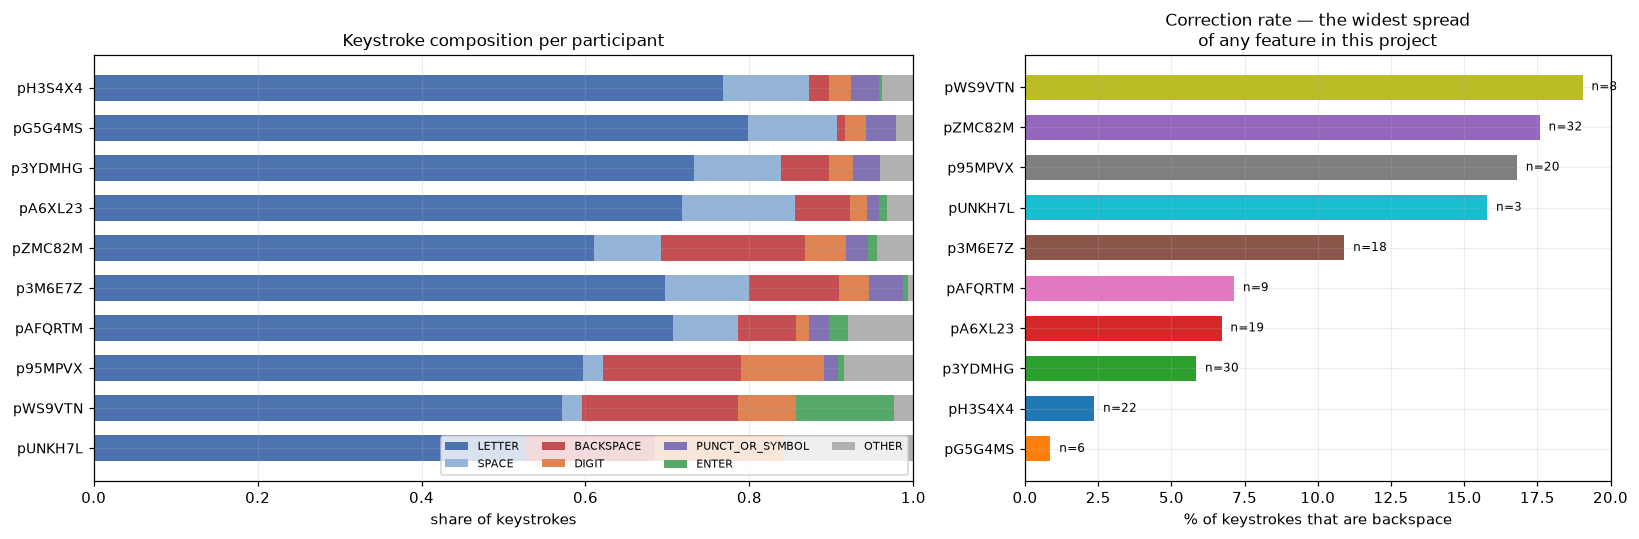

In [3]:
comp = (keys.groupby(['participantId', 'keyClass']).size().unstack(fill_value=0)
        .reindex(columns=KEY_CLASSES, fill_value=0).reindex(PARTICIPANTS))
share = comp.div(comp.sum(axis=1), axis=0)
print("Share of each keystroke class:\n")
print(share.round(3).to_string())
print(f"\nbackspace share ranges {share['BACKSPACE'].min():.1%} to {share['BACKSPACE'].max():.1%} "
      f"-- a factor of {share['BACKSPACE'].max()/max(share['BACKSPACE'].min(),1e-9):.0f}")


def plot_composition(share, comp):
    KCOL = dict(zip(KEY_CLASSES, ['#4c72b0', '#94b4d8', '#c44e52', '#dd8452',
                                  '#8172b3', '#55a868', '#b0b0b0']))
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [1.4, 1]})
    ax = axes[0]
    left = np.zeros(len(share)); y = np.arange(len(share))
    for kc in KEY_CLASSES:
        ax.barh(y, share[kc], left=left, color=KCOL[kc], height=0.66, label=kc)
        left += share[kc].to_numpy()
    ax.set_yticks(y); ax.set_yticklabels(share.index, fontsize=9); ax.invert_yaxis()
    ax.set_xlim(0, 1); ax.set_xlabel("share of keystrokes")
    ax.set_title("Keystroke composition per participant")
    ax.legend(fontsize=7.5, ncol=4, loc='lower right')

    ax = axes[1]
    d = share['BACKSPACE'].sort_values()
    yy = np.arange(len(d))
    ax.barh(yy, d.values * 100, color=[pcolor(p) for p in d.index], height=0.62)
    for i, p in enumerate(d.index):
        ax.text(d[p] * 100 + 0.3, i, f"n={int(comp.loc[p, 'BACKSPACE'])}", va='center', fontsize=8)
    ax.set_yticks(yy); ax.set_yticklabels(d.index, fontsize=9)
    ax.set_xlabel("% of keystrokes that are backspace")
    ax.set_title("Correction rate — the widest spread\nof any feature in this project")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_composition(share, comp)

## 4. Key-class transitions — the digraph substitute

P1 measured the interval for specific letter pairs (`th`, `he`, `in`, `er`). That required
storing what was typed. P2 stores only a 7-way class per keystroke, so the equivalent
measurement is the interval between **classes**.

Three transitions mean physically different things:

- **LETTER→LETTER** — typing speed proper, pure motor execution.
- **LETTER→SPACE** and **SPACE→LETTER** — word boundaries, where lexical decisions happen
  rather than motor execution. These should be *slower* if word-finding costs time.
- **BACKSPACE→BACKSPACE** — deletion speed, a different motor act that need not correlate
  with typing speed at all.

Transitions longer than `MAX_TRANSITION_MS` are dropped: they span a pause rather than a
keystroke pair, and would otherwise re-import the hesitation signal notebook 04 already
measures.

2,816 class transitions under 3000 ms

transition
LETTER->LETTER             1763
SPACE->LETTER               277
LETTER->SPACE               262
OTHER->LETTER               111
BACKSPACE->BACKSPACE        108
LETTER->PUNCT_OR_SYMBOL      81
PUNCT_OR_SYMBOL->SPACE       41
BACKSPACE->LETTER            35
DIGIT->DIGIT                 33
LETTER->BACKSPACE            30


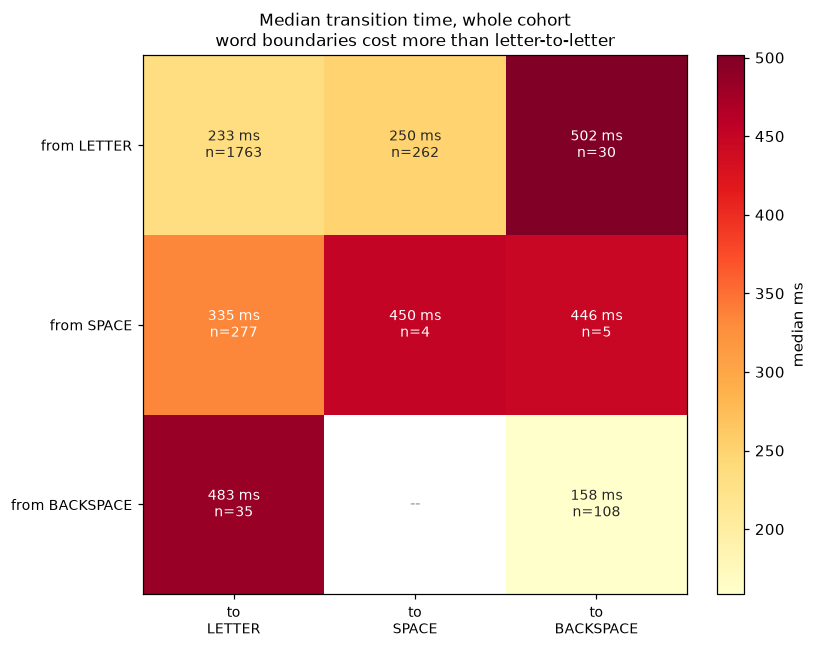

In [4]:
MAX_TRANSITION_MS = 3000.0


def build_transitions(keys_df):
    out = []
    for sid, g in keys_df.groupby('sessionId'):
        g = g.sort_values('tRelMs')
        t = g['tRelMs'].to_numpy(float)
        kc = g['keyClass'].to_numpy()
        if len(t) < 2:
            continue
        dt = np.diff(t)
        pairs = [f"{a}->{b}" for a, b in zip(kc[:-1], kc[1:])]
        ok = dt <= MAX_TRANSITION_MS
        out.append(pd.DataFrame({'participantId': g['participantId'].iloc[0], 'sessionId': sid,
                                 'transition': np.array(pairs)[ok], 'dt_ms': dt[ok]}))
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()


trans = build_transitions(keys)
print(f"{len(trans):,} class transitions under {MAX_TRANSITION_MS:.0f} ms\n")
print(trans['transition'].value_counts().head(10).to_string())


def plot_transition_matrix(trans):
    top = [f"{a}->{b}" for a in ['LETTER', 'SPACE', 'BACKSPACE'] for b in
           ['LETTER', 'SPACE', 'BACKSPACE']]
    med = trans.loc[trans['transition'].isin(top)].groupby('transition')['dt_ms'].median()
    cnt = trans.loc[trans['transition'].isin(top)].groupby('transition').size()
    M = np.full((3, 3), np.nan); N = np.zeros((3, 3), int)
    labs = ['LETTER', 'SPACE', 'BACKSPACE']
    for i, a in enumerate(labs):
        for j, b in enumerate(labs):
            k = f"{a}->{b}"
            if k in med.index:
                M[i, j] = med[k]; N[i, j] = cnt[k]

    fig, ax = plt.subplots(figsize=(7.5, 6))
    im = ax.imshow(M, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(3)); ax.set_xticklabels([f"to\n{l}" for l in labs], fontsize=9)
    ax.set_yticks(range(3)); ax.set_yticklabels([f"from {l}" for l in labs], fontsize=9)
    for i in range(3):
        for j in range(3):
            if np.isfinite(M[i, j]):
                ax.text(j, i, f"{M[i,j]:.0f} ms\nn={N[i,j]}", ha='center', va='center',
                        fontsize=9, color='white' if M[i, j] > np.nanmax(M) * 0.6 else '0.15')
            else:
                ax.text(j, i, "--", ha='center', va='center', fontsize=10, color='0.5')
    ax.set_title("Median transition time, whole cohort\n"
                 "word boundaries cost more than letter-to-letter")
    ax.grid(False)
    plt.colorbar(im, ax=ax, fraction=0.045, label="median ms")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_transition_matrix(trans)

## 5. Transition timing — what the substitute actually measures

The matrix above pools everyone. This section asks whether the substitution *works* as an
identity signal: do people differ from each other on these transitions, and do the three
transition types carry different information?

If LETTER→LETTER and BACKSPACE→BACKSPACE ranked participants identically, one of them would
be redundant. If they rank differently, deletion speed and typing speed are genuinely
separate motor acts — which is what the physical argument predicts.

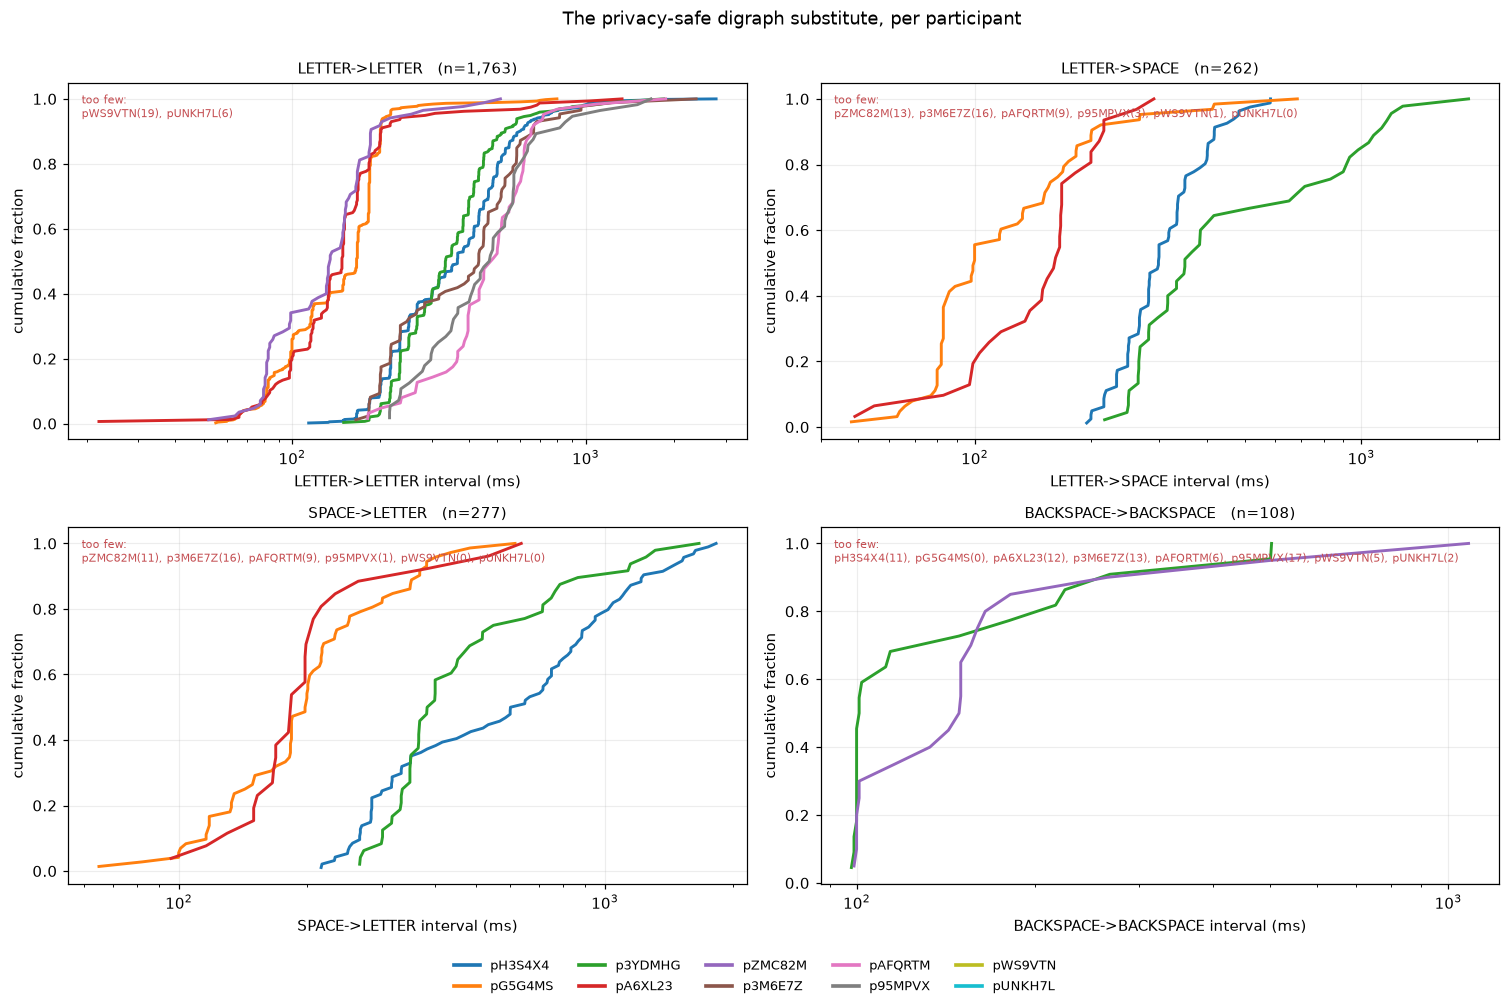

Median transition time per participant (blank = fewer than 20 observations):

transition     BACKSPACE->BACKSPACE  LETTER->LETTER  LETTER->SPACE  SPACE->LETTER
participantId                                                                    
pH3S4X4                         NaN           366.0          299.0          625.0
pG5G4MS                         NaN           166.0          100.0          198.0
p3YDMHG                       101.0           334.0          350.0          391.0
pA6XL23                         NaN           148.0          162.0          184.0
pZMC82M                       150.0           135.0            NaN            NaN
p3M6E7Z                         NaN           433.0            NaN            NaN
pAFQRTM                         NaN           484.0            NaN            NaN
p95MPVX                         NaN           472.0            NaN            NaN
pWS9VTN                         NaN             NaN            NaN            NaN
pUNKH7L             

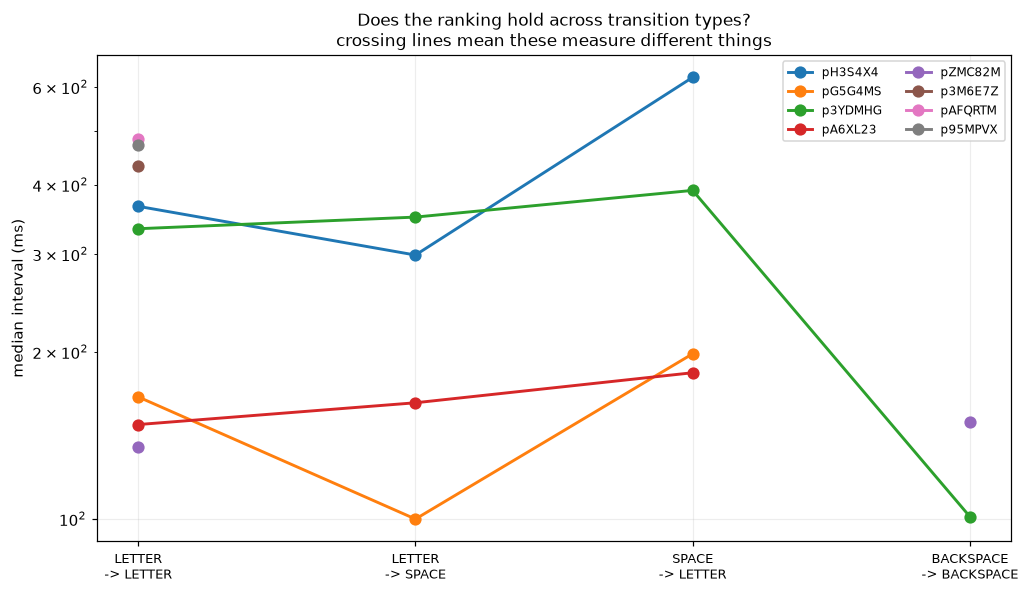

In [16]:
FOCUS = ['LETTER->LETTER', 'LETTER->SPACE', 'SPACE->LETTER', 'BACKSPACE->BACKSPACE']


def plot_transition_ecdfs(trans):
    fig, axes = plt.subplots(2, 2, figsize=(14.5, 9))
    for ax, tr in zip(axes.ravel(), FOCUS):
        d = trans.loc[trans['transition'] == tr]
        thin = []
        for p in PARTICIPANTS:
            v = d.loc[d['participantId'] == p, 'dt_ms'].to_numpy()
            v = np.sort(v[np.isfinite(v) & (v > 0)])
            if len(v) < MIN_EVENTS_FOR_STAT:
                thin.append(f"{p}({len(v)})"); continue
            ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=pcolor(p), lw=1.9)
        ax.set_xscale('log'); ax.set_xlabel(f"{tr} interval (ms)")
        ax.set_ylabel("cumulative fraction")
        ax.set_title(f"{tr}   (n={len(d):,})", fontsize=10)
        if thin:
            ax.text(0.02, 0.97, "too few:\n" + ", ".join(thin), transform=ax.transAxes,
                    va='top', fontsize=7, color='#c44e52')
    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4, label=p) for p in PARTICIPANTS]
    fig.legend(handles=handles, loc='lower center', ncol=5, frameon=False, fontsize=8.5)
    fig.suptitle("The privacy-safe digraph substitute, per participant", y=1.0)
    plt.tight_layout(rect=[0, 0.05, 1, 1]); plt.show(); plt.close(fig)


plot_transition_ecdfs(trans)


def plot_transition_ranking(trans):
    med = (trans.loc[trans['transition'].isin(FOCUS)]
           .groupby(['participantId', 'transition'])['dt_ms'].median().unstack())
    cnt = (trans.loc[trans['transition'].isin(FOCUS)]
           .groupby(['participantId', 'transition']).size().unstack().fillna(0))
    med = med.reindex(PARTICIPANTS)
    med_masked = med.where(cnt.reindex(PARTICIPANTS) >= MIN_EVENTS_FOR_STAT)
    print("Median transition time per participant (blank = fewer than "
          f"{MIN_EVENTS_FOR_STAT} observations):\n")
    print(med_masked.round(0).to_string())

    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    x = np.arange(len(FOCUS))
    for p in PARTICIPANTS:
        vals = [med_masked.loc[p, t] if t in med_masked.columns else np.nan for t in FOCUS]
        if all(pd.isna(v) for v in vals):
            continue
        ax.plot(x, vals, 'o-', color=pcolor(p), lw=1.9, markersize=7, label=p)
    ax.set_xticks(x); ax.set_xticklabels([t.replace('->', '\n-> ') for t in FOCUS], fontsize=8.5)
    ax.set_yscale('log'); ax.set_ylabel("median interval (ms)")
    ax.set_title("Does the ranking hold across transition types?\n"
                 "crossing lines mean these measure different things")
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_transition_ranking(trans)

## 6. Correction: how much, and in what shape

Backspace *share* (Section 3) says how often someone corrects. It says nothing about
**how**. Deleting one mistyped character and wiping an entire field are both "a backspace",
but they are different acts:

- **`backspace_run_length`** — consecutive deletions in one go. A run of 1 is a typo fix; a
  run of 12 is starting the field over.
- **`runs_per_session`** — how many separate correction episodes there were.

A person with a high backspace share and short runs is making frequent small errors. High
share with long runs means fewer, bigger restarts. These are opposite behaviours that
produce the same summary number.

Backspace runs -- a 'run' is consecutive deletions with no other key between:

               n_runs  median_run  max_run  total_deleted
participantId                                            
pH3S4X4            11         2.0        6             22
pG5G4MS             6         1.0        1              6
p3YDMHG             7         2.0       14             30
pA6XL23             7         3.0        6             19
pZMC82M            12         2.0        9             32
p3M6E7Z             5         1.0       14             18
pAFQRTM             3         3.0        5              9
p95MPVX             3         5.0       11             20
pWS9VTN             3         2.0        5              8
pUNKH7L             1         3.0        3              3


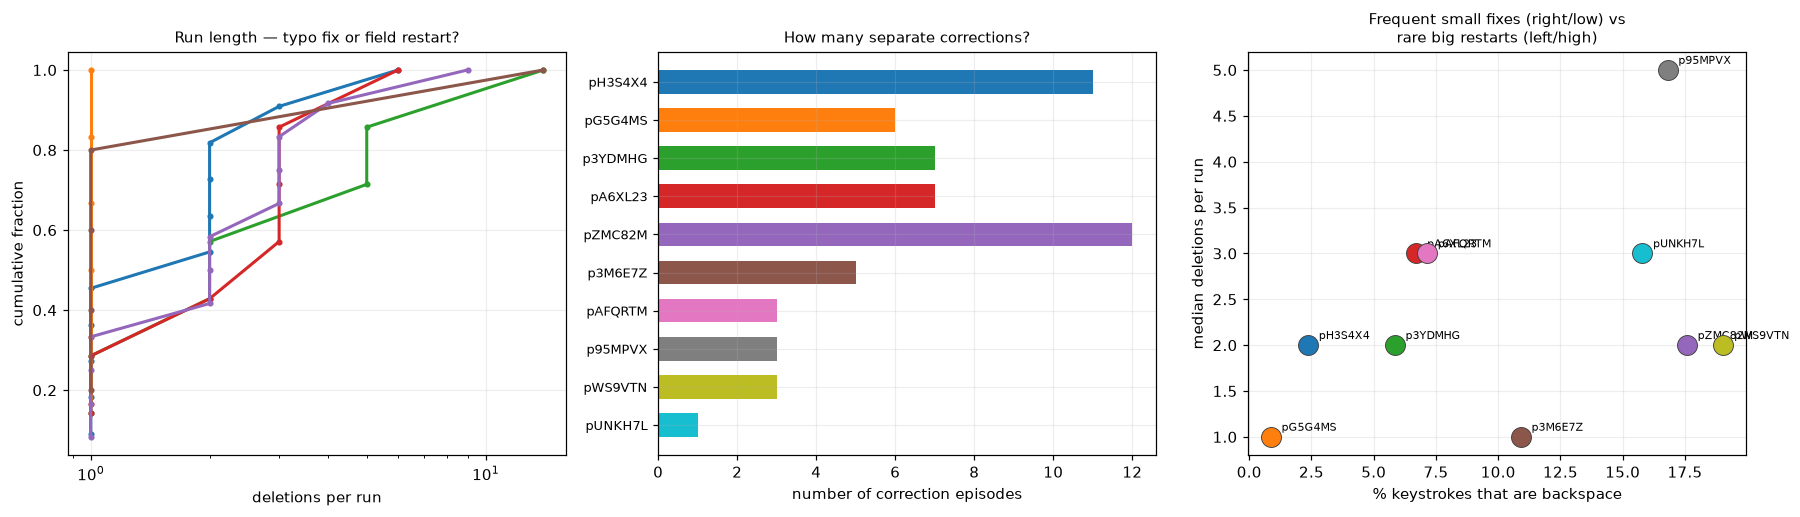

In [6]:
def backspace_runs(keys_df):
    out = []
    for sid, g in keys_df.groupby('sessionId'):
        g = g.sort_values('tRelMs')
        kc = g['keyClass'].to_numpy()
        is_bs = kc == 'BACKSPACE'
        if not is_bs.any():
            continue
        run = 0
        for i, b in enumerate(is_bs):
            if b:
                run += 1
            elif run:
                out.append({'participantId': g['participantId'].iloc[0], 'sessionId': sid,
                            'run_length': run})
                run = 0
        if run:
            out.append({'participantId': g['participantId'].iloc[0], 'sessionId': sid,
                        'run_length': run})
    return pd.DataFrame(out)


runs = backspace_runs(keys)
run_summ = (runs.groupby('participantId')
            .agg(n_runs=('run_length', 'size'), median_run=('run_length', 'median'),
                 max_run=('run_length', 'max'), total_deleted=('run_length', 'sum'))
            .reindex(PARTICIPANTS))
print("Backspace runs -- a 'run' is consecutive deletions with no other key between:\n")
print(run_summ.to_string())


def plot_correction(share, runs, run_summ):
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))
    ax = axes[0]
    for p in PARTICIPANTS:
        v = runs.loc[runs['participantId'] == p, 'run_length'].to_numpy()
        if len(v) < 5:
            continue
        v = np.sort(v)
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=pcolor(p), lw=2,
                marker='o', markersize=3)
    ax.set_xscale('log'); ax.set_xlabel("deletions per run")
    ax.set_ylabel("cumulative fraction")
    ax.set_title("Run length — typo fix or field restart?", fontsize=10)

    ax = axes[1]
    d = run_summ.dropna(subset=['n_runs'])
    y = np.arange(len(d))
    ax.barh(y, d['n_runs'], color=[pcolor(p) for p in d.index], height=0.62)
    ax.set_yticks(y); ax.set_yticklabels(d.index, fontsize=8.5); ax.invert_yaxis()
    ax.set_xlabel("number of correction episodes")
    ax.set_title("How many separate corrections?", fontsize=10)

    ax = axes[2]
    for p in PARTICIPANTS:
        if p not in run_summ.index or pd.isna(run_summ.loc[p, 'median_run']):
            continue
        ax.scatter(share.loc[p, 'BACKSPACE'] * 100, run_summ.loc[p, 'median_run'],
                   s=170, color=pcolor(p), edgecolor='0.25', lw=0.6, zorder=3)
        ax.annotate(p, (share.loc[p, 'BACKSPACE'] * 100, run_summ.loc[p, 'median_run']),
                    fontsize=7.5, xytext=(7, 4), textcoords='offset points')
    ax.set_xlabel("% keystrokes that are backspace")
    ax.set_ylabel("median deletions per run")
    ax.set_title("Frequent small fixes (right/low) vs\nrare big restarts (left/high)", fontsize=10)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_correction(share, runs, run_summ)

## 7. Hold or tap — two ways to delete

`payload_repeat` marks a keystroke generated by **holding** a key rather than pressing it.
Clearing a field by holding backspace and clearing it by tapping backspace eleven times
produce nearly identical keystroke counts and completely different physical behaviour.

This is a strategy choice, not a speed measurement — which makes it one of the few features
in this project with no obvious route back to pace.

Autorepeat -- keystrokes produced by holding a key down:

               n_keys  n_repeat  repeat_pct  bs_repeat_pct  n_backspace
participantId                                                          
pH3S4X4           930         0        0.00           0.00           22
pG5G4MS           691         0        0.00           0.00            6
p3YDMHG           513        17        3.31          56.67           30
pA6XL23           283         0        0.00           0.00           19
pZMC82M           182         8        4.40          25.00           32
p3M6E7Z           165        13        7.88          72.22           18
pAFQRTM           126         0        0.00           0.00            9
p95MPVX           119         0        0.00           0.00           20
pWS9VTN            42         0        0.00           0.00            8
pUNKH7L            19         0        0.00           0.00            3


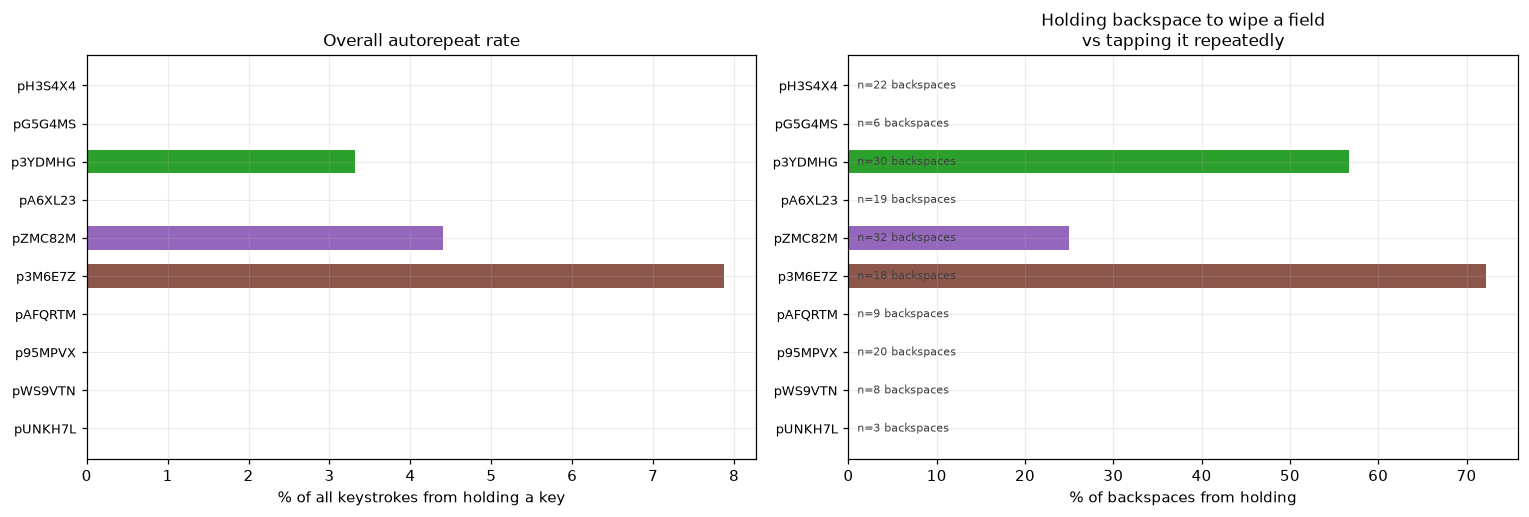

In [7]:
keys['is_repeat'] = keys['payload_repeat'].astype(str).str.lower().isin(['true', '1'])
rep = (keys.groupby('participantId')
       .agg(n_keys=('is_repeat', 'size'), n_repeat=('is_repeat', 'sum'))
       .reindex(PARTICIPANTS))
rep['repeat_pct'] = (100 * rep['n_repeat'] / rep['n_keys']).round(2)
bs = keys.loc[keys['keyClass'] == 'BACKSPACE']
rep['bs_repeat_pct'] = (100 * bs.groupby('participantId')['is_repeat'].mean()).reindex(PARTICIPANTS).round(2)
rep['n_backspace'] = bs.groupby('participantId').size().reindex(PARTICIPANTS)
print("Autorepeat -- keystrokes produced by holding a key down:\n")
print(rep.to_string())


def plot_autorepeat(rep):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    ax = axes[0]
    d = rep.dropna(subset=['repeat_pct'])
    y = np.arange(len(d))
    ax.barh(y, d['repeat_pct'], color=[pcolor(p) for p in d.index], height=0.62)
    ax.set_yticks(y); ax.set_yticklabels(d.index, fontsize=8.5); ax.invert_yaxis()
    ax.set_xlabel("% of all keystrokes from holding a key")
    ax.set_title("Overall autorepeat rate")

    ax = axes[1]
    d2 = rep.dropna(subset=['bs_repeat_pct'])
    y = np.arange(len(d2))
    ax.barh(y, d2['bs_repeat_pct'], color=[pcolor(p) for p in d2.index], height=0.62)
    for i, p in enumerate(d2.index):
        ax.text(1, i, f"n={int(d2.loc[p,'n_backspace'])} backspaces", va='center',
                fontsize=7.5, color='0.25')
    ax.set_yticks(y); ax.set_yticklabels(d2.index, fontsize=8.5); ax.invert_yaxis()
    ax.set_xlabel("% of backspaces from holding")
    ax.set_title("Holding backspace to wipe a field\nvs tapping it repeatedly")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_autorepeat(rep)

## 8. Caret repositioning — navigating versus deleting back

When someone spots an error three words back, they have two options: delete everything
between here and there, or move the caret to the error and fix it in place.

`payload_selectionStart` against `payload_valueLength` reveals which. If the caret sits
**before** the end of the text, the person navigated into it. If it is always at the end,
they only ever delete backwards.

This is a genuine strategy difference and costs nothing in privacy — the caret position says
nothing about what was typed.

Caret position relative to end of text:

                 n  reposition_pct
participantId                     
pH3S4X4        832            0.36
pG5G4MS        629            0.00
p3YDMHG        462            0.65
pA6XL23        259            4.25
pZMC82M        162            1.23
p3M6E7Z        153            3.92
pAFQRTM        111            1.80
p95MPVX         94            0.00
pWS9VTN         37            0.00
pUNKH7L         13            0.00


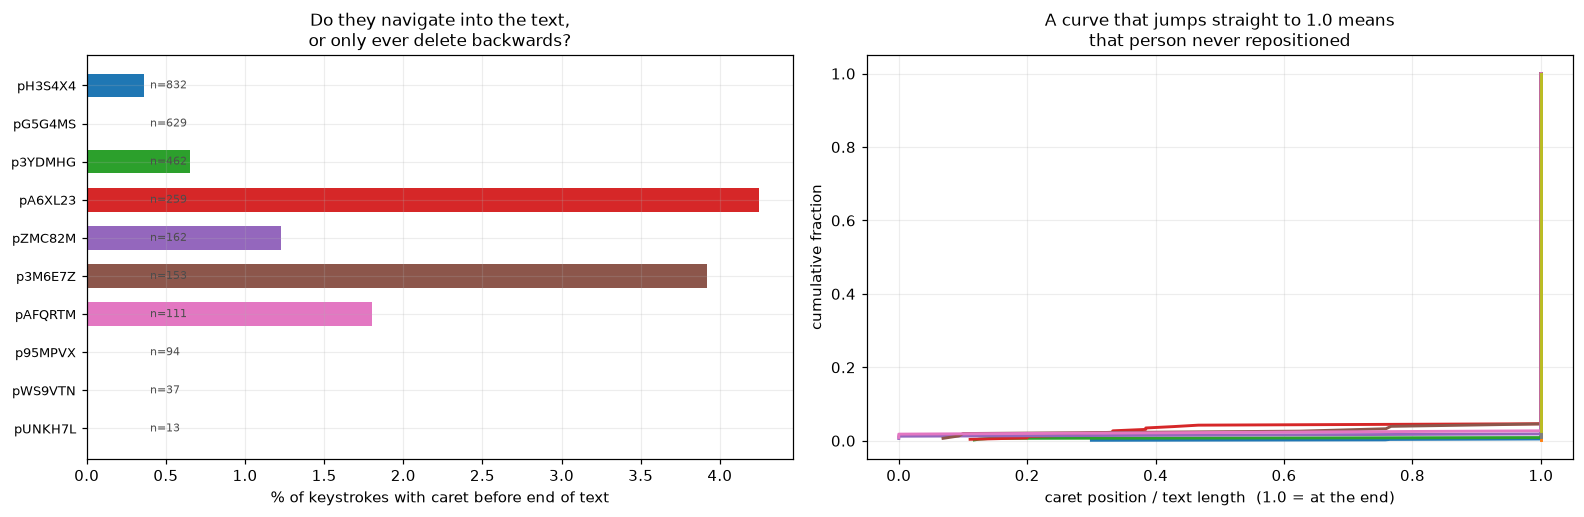

In [8]:
keys['sel_start'] = pd.to_numeric(keys['payload_selectionStart'], errors='coerce')
keys['val_len'] = pd.to_numeric(keys['payload_valueLength'], errors='coerce')
kv = keys.dropna(subset=['sel_start', 'val_len'])
kv = kv.loc[kv['val_len'] > 0].copy()
kv['caret_frac'] = kv['sel_start'] / kv['val_len']
kv['repositioned'] = kv['caret_frac'] < 0.99

caret = (kv.groupby('participantId')
         .agg(n=('repositioned', 'size'), reposition_pct=('repositioned', 'mean'))
         .reindex(PARTICIPANTS))
caret['reposition_pct'] = (100 * caret['reposition_pct']).round(2)
print("Caret position relative to end of text:\n")
print(caret.to_string())


def plot_caret(caret, kv):
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8))
    ax = axes[0]
    d = caret.dropna(subset=['reposition_pct'])
    y = np.arange(len(d))
    ax.barh(y, d['reposition_pct'], color=[pcolor(p) for p in d.index], height=0.62)
    for i, p in enumerate(d.index):
        ax.text(0.4, i, f"n={int(d.loc[p,'n'])}", va='center', fontsize=7.5, color='0.3')
    ax.set_yticks(y); ax.set_yticklabels(d.index, fontsize=8.5); ax.invert_yaxis()
    ax.set_xlabel("% of keystrokes with caret before end of text")
    ax.set_title("Do they navigate into the text,\nor only ever delete backwards?")

    ax = axes[1]
    for p in PARTICIPANTS:
        v = kv.loc[kv['participantId'] == p, 'caret_frac'].to_numpy()
        v = v[np.isfinite(v) & (v >= 0) & (v <= 1.05)]
        if len(v) < MIN_EVENTS_FOR_STAT:
            continue
        v = np.sort(v)
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=pcolor(p), lw=1.9)
    ax.set_xlabel("caret position / text length  (1.0 = at the end)")
    ax.set_ylabel("cumulative fraction")
    ax.set_title("A curve that jumps straight to 1.0 means\nthat person never repositioned")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_caret(caret, kv)

## 9. Does the task confound the editing features?

The tasks require typing specific content, and the amount is not identical every time. That
matters: if longer prompts elicit more mistakes, then backspace share would partly be
measuring **which text someone was asked to type** rather than how they type.

Three checks, all plotted rather than asserted:

1. **Is the amount typed systematic by participant?** If one person consistently types more,
   their correction rate is not directly comparable to anyone else's.
2. **Does correction rate track text length?** The direct test of the confound.
3. **Does the ranking survive inside each task type?** If the same person is the heaviest
   corrector in every task separately, the effect is not a task artefact.

149 typing episodes (one per task INSTANCE, not per task type)

               size  median
taskType                   
guided_note      45   0.000
guided_reply     46   0.000
pots_transfer     2   0.417
typing_search    56   0.000


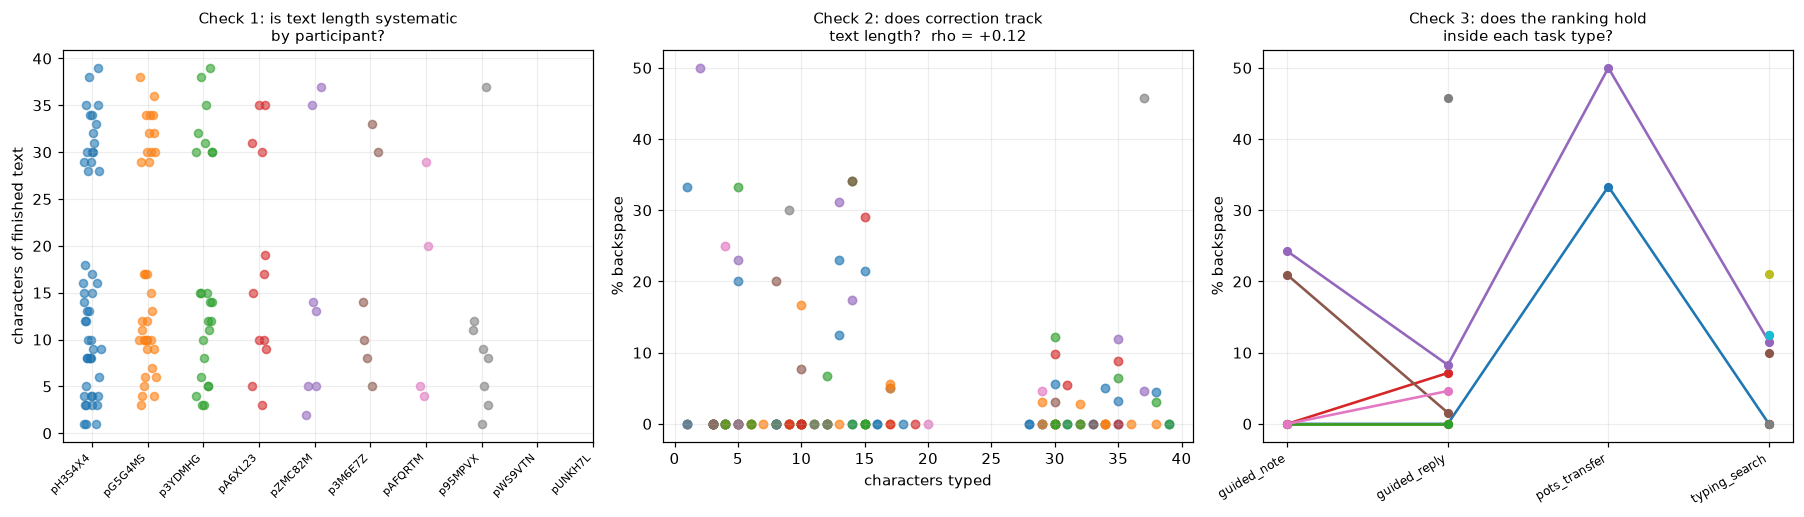


Spearman correlation, text length vs backspace rate: +0.12


In [9]:
_ts = raw.loc[raw['kind'] == 'task_start', ['sessionId', 'tRelMs', 'payload_taskType']].copy()
_ts = _ts.sort_values(['sessionId', 'tRelMs'])
_ts['t_end'] = _ts.groupby('sessionId')['tRelMs'].shift(-1)
_ends = raw.groupby('sessionId')['tRelMs'].max()
_ts['t_end'] = _ts['t_end'].fillna(_ts['sessionId'].map(_ends))


# Each typing task TYPE occurs twice per session (tasks 3-13 repeat as 14-24),
# so a task_instance id is required. Grouping by taskType alone would pool two
# separate text fields while valueLength.max() reflects only one of them, which
# inflates keys_per_char by roughly the number of instances pooled.
def attach_task(keys_df, ts):
    out = []
    for sid, g in keys_df.groupby('sessionId'):
        tt = ts.loc[ts['sessionId'] == sid]
        g = g.copy(); g['taskType'] = None; g['task_instance'] = None
        for n, r in enumerate(tt.itertuples()):
            mask = (g['tRelMs'] >= r.tRelMs) & (g['tRelMs'] < r.t_end)
            g.loc[mask, 'taskType'] = r.payload_taskType
            g.loc[mask, 'task_instance'] = f"{sid[:8]}_{n:02d}"
        out.append(g)
    return pd.concat(out, ignore_index=True)


keys_t = attach_task(keys, _ts)
keys_t = keys_t.loc[keys_t['taskType'].notna()]

burst = (keys_t.groupby(['participantId', 'sessionId', 'taskType', 'task_instance'])
         .agg(n_keys=('keyClass', 'size'),
              n_bs=('keyClass', lambda s: (s == 'BACKSPACE').sum()),
              final_len=('val_len', 'max')).reset_index())
burst = burst.loc[burst['n_keys'] >= 3]
burst['bs_rate'] = burst['n_bs'] / burst['n_keys']
print(f"{len(burst)} typing episodes (one per task INSTANCE, not per task type)\n")
print(burst.groupby('taskType')['bs_rate'].agg(['size', 'median']).round(3).to_string())


def plot_task_confound(burst):
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))
    ax = axes[0]
    for p in PARTICIPANTS:
        d = burst.loc[burst['participantId'] == p, 'final_len'].dropna()
        if len(d) < 3:
            continue
        ax.scatter(np.full(len(d), PARTICIPANTS.index(p)) +
                   np.random.uniform(-0.16, 0.16, len(d)), d, s=28, alpha=0.6, color=pcolor(p))
    ax.set_xticks(range(len(PARTICIPANTS)))
    ax.set_xticklabels(PARTICIPANTS, rotation=45, ha='right', fontsize=7.5)
    ax.set_ylabel("characters of finished text")
    ax.set_title("Check 1: is text length systematic\nby participant?", fontsize=9.5)

    ax = axes[1]
    d = burst.dropna(subset=['final_len'])
    d = d.loc[d['final_len'] > 0]
    for p in PARTICIPANTS:
        dd = d.loc[d['participantId'] == p]
        if len(dd) < 3:
            continue
        ax.scatter(dd['final_len'], dd['bs_rate'] * 100, s=30, alpha=0.65, color=pcolor(p))
    rho = d['final_len'].corr(d['bs_rate'], method='spearman')
    ax.set_xlabel("characters typed"); ax.set_ylabel("% backspace")
    ax.set_title(f"Check 2: does correction track\ntext length?  rho = {rho:+.2f}", fontsize=9.5)

    ax = axes[2]
    tt = (burst.groupby(['taskType', 'participantId'])['bs_rate'].median().unstack())
    tt = tt.reindex(columns=[p for p in PARTICIPANTS if p in tt.columns])
    for p in tt.columns:
        ax.plot(range(len(tt)), tt[p].to_numpy() * 100, 'o-', color=pcolor(p), lw=1.7,
                markersize=5)
    ax.set_xticks(range(len(tt)))
    ax.set_xticklabels(tt.index, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel("% backspace")
    ax.set_title("Check 3: does the ranking hold\ninside each task type?", fontsize=9.5)
    plt.tight_layout(); plt.show(); plt.close(fig)
    print(f"\nSpearman correlation, text length vs backspace rate: {rho:+.2f}")


plot_task_confound(burst)

## 10. The fix: normalise by text, condition on task

Two changes follow from the checks above.

**`keys_per_char`** — keystrokes pressed per character of finished text — normalises effort
by how much text the task actually demanded. It also counts *all* wasted keystrokes rather
than only deletions, so someone who retypes a word without deleting it is measured too.
A value of 1.0 is perfect efficiency; 1.5 means half again as many presses as characters
produced.

**Task-conditioned comparison.** Even though text length does not drive the correction rate,
task type shifts its *level* — some tasks elicit several times the correction rate of others
for everyone. Comparing within task type removes that shared variance.

Keystrokes per character of finished text (1.0 = perfectly efficient):

               n_episodes  median_kpc
participantId                        
pH3S4X4                49       1.111
pG5G4MS                35       1.100
p3YDMHG                24       1.150
pA6XL23                12       1.197
pZMC82M                 7       1.643
p3M6E7Z                 6       1.250
pAFQRTM                 4       2.421
p95MPVX                 8       1.336
pWS9VTN                 2       2.452
pUNKH7L                 2       3.200


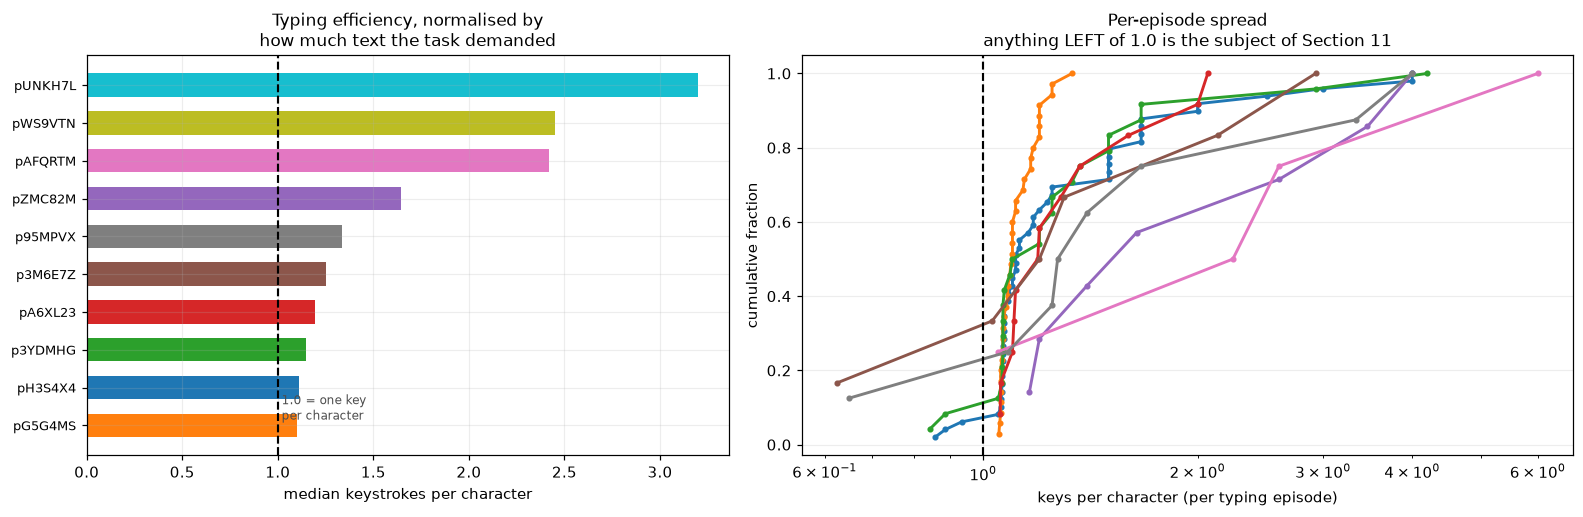

In [10]:
burst['keys_per_char'] = burst['n_keys'] / burst['final_len'].replace(0, np.nan)
kpc = (burst.groupby('participantId')
       .agg(n_episodes=('keys_per_char', 'size'), median_kpc=('keys_per_char', 'median'))
       .reindex(PARTICIPANTS))
print("Keystrokes per character of finished text (1.0 = perfectly efficient):\n")
print(kpc.round(3).to_string())


def plot_kpc(burst, kpc):
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8), gridspec_kw={'width_ratios': [1, 1.2]})
    ax = axes[0]
    d = kpc.dropna(subset=['median_kpc']).sort_values('median_kpc')
    y = np.arange(len(d))
    ax.barh(y, d['median_kpc'], color=[pcolor(p) for p in d.index], height=0.62)
    ax.axvline(1.0, color='k', ls='--', lw=1.4)
    ax.text(1.02, 0.15, "1.0 = one key\nper character", fontsize=8, color='0.3')
    ax.set_yticks(y); ax.set_yticklabels(d.index, fontsize=8.5)
    ax.set_xlabel("median keystrokes per character")
    ax.set_title("Typing efficiency, normalised by\nhow much text the task demanded")

    ax = axes[1]
    for p in PARTICIPANTS:
        v = burst.loc[burst['participantId'] == p, 'keys_per_char'].dropna().to_numpy()
        v = v[np.isfinite(v) & (v > 0)]
        if len(v) < 4:
            continue
        v = np.sort(v)
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=pcolor(p), lw=1.9,
                marker='o', markersize=3)
    ax.axvline(1.0, color='k', ls='--', lw=1.4)
    ax.set_xscale('log'); ax.set_xlabel("keys per character (per typing episode)")
    ax.set_ylabel("cumulative fraction")
    ax.set_title("Per-episode spread\nanything LEFT of 1.0 is the subject of Section 11")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_kpc(burst, kpc)

## 11. Predictive text, found by accident

`keys_per_char` **below 1** means more characters appeared than keys were pressed. That is
only possible if the keyboard supplied some of them — an accepted autocomplete suggestion,
or a paste.

So a feature built to normalise effort turns out to double as a **predictive-text detector**,
without needing any content and without the `beforeinput` route that Section 14 shows does
not work here.

The `beforeinput` stream provides an independent check: `insertReplacementText` is the event
type a keyboard suggestion produces. If the two methods agreed on who uses autocomplete, both
would probably be right.

**They do not agree, and the honest reading is that neither is usable here.** Only 5 typing
episodes across the entire cohort have `keys_per_char < 1`, and the participant with the most
`beforeinput` replacements is not among those who show sub-1 episodes. Two independent
measurements disagreeing means at least one is wrong, and with this little typing there is no
way to tell which. The mechanism is sound in principle — a keyboard-supplied character really
does produce fewer keystrokes than characters — but the effect is too rare in this dataset to
detect reliably.

Two routes that SHOULD agree, and do not:

               episodes  episodes_kpc_under_1  pct_episodes  beforeinput_replacements
participantId                                                                        
pH3S4X4              49                     3           6.1                         8
pG5G4MS              35                     0           0.0                        11
p3YDMHG              24                     2           8.3                         7
pA6XL23              12                     0           0.0                        11
pZMC82M               7                     0           0.0                         4
p3M6E7Z               6                     1          16.7                         4
pAFQRTM               4                     0           0.0                         6
p95MPVX               8                     1          12.5                        17
pWS9VTN               2                     0           0.0                         5
pUNKH7L    

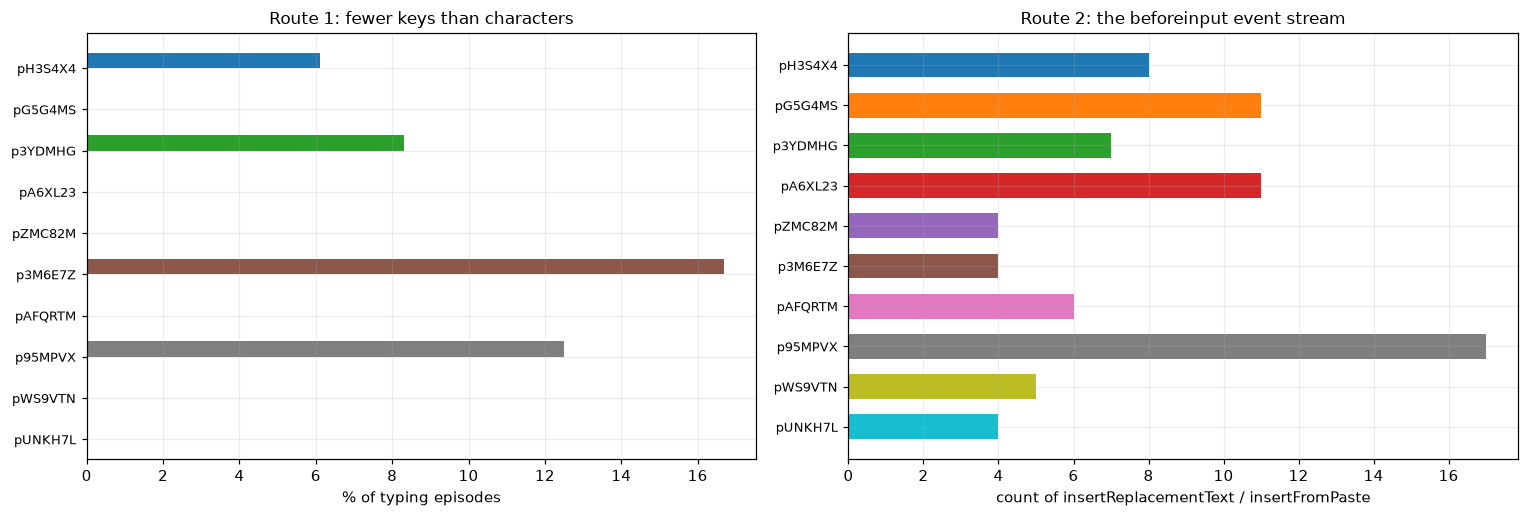

In [11]:
sub_one = burst.loc[burst['keys_per_char'] < 1].groupby('participantId').size()
tot_ep = burst.groupby('participantId').size()
pred = pd.DataFrame({'episodes': tot_ep, 'episodes_kpc_under_1': sub_one}).reindex(PARTICIPANTS)
pred['episodes_kpc_under_1'] = pred['episodes_kpc_under_1'].fillna(0).astype(int)
pred['pct_episodes'] = (100 * pred['episodes_kpc_under_1'] / pred['episodes']).round(1)

bi = raw.loc[raw['kind'] == BEFORE_INPUT].copy()
bi_repl = bi.loc[bi['payload_inputType'].isin(['insertReplacementText', 'insertFromPaste'])]
pred['beforeinput_replacements'] = bi_repl.groupby('participantId').size().reindex(PARTICIPANTS).fillna(0).astype(int)
print("Two routes that SHOULD agree, and do not:\n")
print(pred.to_string())
print()
print(f"Only {int(pred['episodes_kpc_under_1'].sum())} episodes across the whole cohort have")
print("keys_per_char < 1, and the participant with the most beforeinput replacements")
print("(pA6XL23, n=11) has none of them. Treat both routes as undetectable at this volume.")


def plot_predictive(pred):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    ax = axes[0]
    d = pred.dropna(subset=['pct_episodes'])
    y = np.arange(len(d)); w = 0.38
    ax.barh(y - w / 2, d['pct_episodes'], height=w,
            color=[pcolor(p) for p in d.index], label='% episodes with keys_per_char < 1')
    ax.set_yticks(y); ax.set_yticklabels(d.index, fontsize=8.5); ax.invert_yaxis()
    ax.set_xlabel("% of typing episodes")
    ax.set_title("Route 1: fewer keys than characters")

    ax = axes[1]
    ax.barh(y, d['beforeinput_replacements'], color=[pcolor(p) for p in d.index], height=0.62)
    ax.set_yticks(y); ax.set_yticklabels(d.index, fontsize=8.5); ax.invert_yaxis()
    ax.set_xlabel("count of insertReplacementText / insertFromPaste")
    ax.set_title("Route 2: the beforeinput event stream")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_predictive(pred)

## 12. Typing bursts — rhythm above the keystroke

Keystrokes arrive in runs, not evenly. A **burst** is a stretch of typing with no long gap —
roughly a word or phrase produced in one go. It is the natural unit one level up from the
individual keystroke, and it has properties the keystroke does not:

- **burst length** — how many keys before pausing. Long bursts suggest composing fluently;
  short ones suggest working word by word.
- **inter-burst gap** — the thinking time between runs.

This is the typing equivalent of the scroll-burst analysis in notebook 06.

330 typing bursts (gap > 1500 ms starts a new one):

               n_bursts  median_len  median_gap_ms
participantId                                     
pH3S4X4              99         5.0        22525.0
pG5G4MS              49        11.0        12185.0
p3YDMHG              57         5.0        20857.0
pA6XL23              19        11.0        21985.0
pZMC82M              18         4.5        15739.0
p3M6E7Z              30         3.0         7954.0
pAFQRTM              23         4.0         7683.0
p95MPVX              24         4.5        52413.0
pWS9VTN               6         2.5        72978.0
pUNKH7L               5         4.0        65281.5


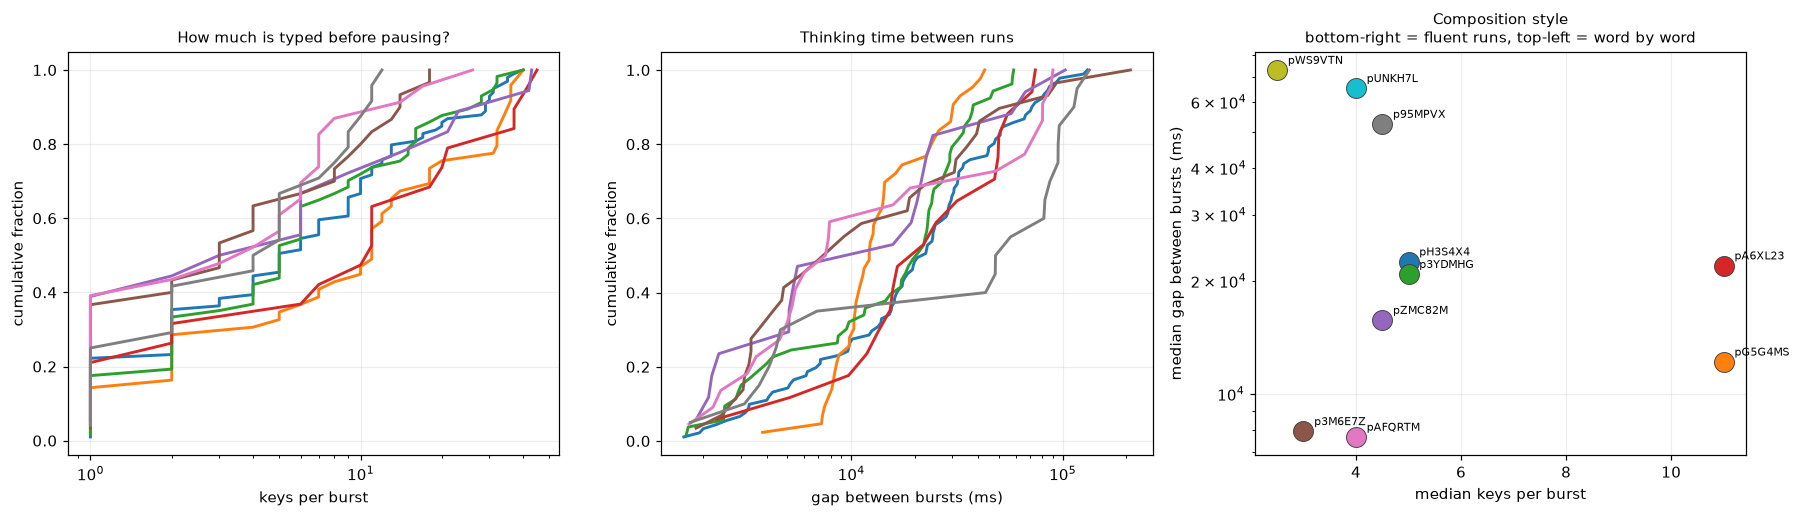

In [12]:
BURST_GAP_MS = 1500.0


def typing_bursts(keys_df, gap_ms=BURST_GAP_MS):
    out = []
    for sid, g in keys_df.groupby('sessionId'):
        g = g.sort_values('tRelMs')
        t = g['tRelMs'].to_numpy(float)
        if len(t) < 2:
            continue
        brk = np.where(np.diff(t) > gap_ms)[0]
        groups = np.split(t, brk + 1)
        starts = [x[0] for x in groups]
        gaps = np.concatenate([[np.nan], np.diff(starts)])
        for grp, gp in zip(groups, gaps):
            out.append({'participantId': g['participantId'].iloc[0], 'sessionId': sid,
                        'n_keys': len(grp), 'duration_ms': grp[-1] - grp[0], 'gap_ms': gp})
    return pd.DataFrame(out)


tb = typing_bursts(keys)
tb_summ = (tb.groupby('participantId')
           .agg(n_bursts=('n_keys', 'size'), median_len=('n_keys', 'median'),
                median_gap_ms=('gap_ms', 'median')).reindex(PARTICIPANTS))
print(f"{len(tb)} typing bursts (gap > {BURST_GAP_MS:.0f} ms starts a new one):\n")
print(tb_summ.round(1).to_string())


def plot_typing_bursts(tb, tb_summ):
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))
    ax = axes[0]
    for p in PARTICIPANTS:
        v = tb.loc[tb['participantId'] == p, 'n_keys'].to_numpy()
        if len(v) < 8:
            continue
        v = np.sort(v)
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=pcolor(p), lw=1.9)
    ax.set_xscale('log'); ax.set_xlabel("keys per burst"); ax.set_ylabel("cumulative fraction")
    ax.set_title("How much is typed before pausing?", fontsize=10)

    ax = axes[1]
    for p in PARTICIPANTS:
        v = tb.loc[tb['participantId'] == p, 'gap_ms'].dropna().to_numpy()
        if len(v) < 8:
            continue
        v = np.sort(v)
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=pcolor(p), lw=1.9)
    ax.set_xscale('log'); ax.set_xlabel("gap between bursts (ms)")
    ax.set_ylabel("cumulative fraction")
    ax.set_title("Thinking time between runs", fontsize=10)

    ax = axes[2]
    d = tb_summ.dropna(subset=['median_len', 'median_gap_ms'])
    for p, r in d.iterrows():
        ax.scatter(r['median_len'], r['median_gap_ms'], s=170, color=pcolor(p),
                   edgecolor='0.25', lw=0.6, zorder=3)
        ax.annotate(p, (r['median_len'], r['median_gap_ms']), fontsize=7.5,
                    xytext=(7, 4), textcoords='offset points')
    ax.set_xlabel("median keys per burst"); ax.set_ylabel("median gap between bursts (ms)")
    ax.set_yscale('log')
    ax.set_title("Composition style\nbottom-right = fluent runs, top-left = word by word",
                 fontsize=10)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_typing_bursts(tb, tb_summ)

## 13. Does any of this hold within a person?

Everything above pools all of a participant's sessions. The question that matters for a model
is whether these properties are stable for one person across their own repeat visits.

Shown, not scored. Each participant's session-level values are plotted as points joined by a
line — **short vertical spread means a stable trait; a long line means the pooled number was
hiding real session-to-session variation.** Only participants with more than one session can
appear, and typing volume per session is small enough that some points rest on very few
keystrokes.

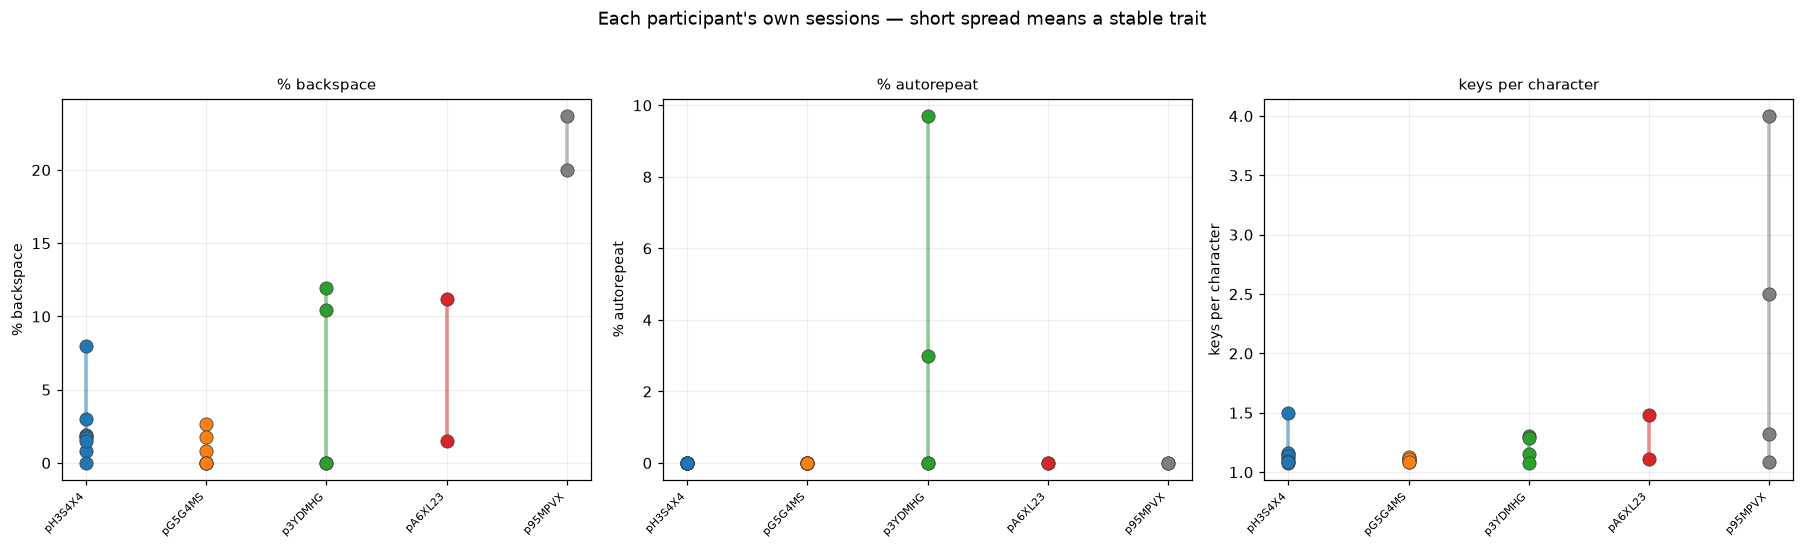

participants with >1 session and enough typing: pH3S4X4, pG5G4MS, p3YDMHG, pA6XL23, p95MPVX


In [13]:
def plot_within_person(keys, burst):
    multi = [p for p in PARTICIPANTS if (session_index['participantId'] == p).sum() > 1]
    per_sess = (keys.groupby(['participantId', 'sessionId'])
                .agg(n=('keyClass', 'size'),
                     bs_pct=('keyClass', lambda s: 100 * (s == 'BACKSPACE').mean()),
                     rep_pct=('is_repeat', lambda s: 100 * s.mean())).reset_index())
    per_sess = per_sess.loc[per_sess['n'] >= MIN_EVENTS_FOR_STAT]
    kpc_sess = burst.groupby(['participantId', 'sessionId'])['keys_per_char'].median().reset_index()

    panels = [(per_sess, 'bs_pct', '% backspace'),
              (per_sess, 'rep_pct', '% autorepeat'),
              (kpc_sess, 'keys_per_char', 'keys per character')]
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))
    for ax, (src, col, lab) in zip(axes, panels):
        for i, p in enumerate(multi):
            v = src.loc[src['participantId'] == p, col].dropna().to_numpy()
            if len(v) == 0:
                continue
            ax.scatter(np.full(len(v), i), v, s=75, color=pcolor(p), edgecolor='0.25',
                       lw=0.5, zorder=3)
            if len(v) > 1:
                ax.plot([i, i], [v.min(), v.max()], color=pcolor(p), lw=2.4, alpha=0.5, zorder=2)
        ax.set_xticks(range(len(multi)))
        ax.set_xticklabels(multi, rotation=45, ha='right', fontsize=7.5)
        ax.set_ylabel(lab, fontsize=9); ax.set_title(lab, fontsize=10)
    fig.suptitle("Each participant's own sessions — short spread means a stable trait", y=1.03)
    plt.tight_layout(); plt.show(); plt.close(fig)
    print(f"participants with >1 session and enough typing: {', '.join(multi)}")


plot_within_person(keys, burst)

## 14. Data-quality notes and rejected derivations

- **Typing volume is the binding constraint.** 2,330 keystrokes across the whole cohort, from
  19 to 726 per participant — a 38x range. Nothing here is robust for the thin participants,
  and the availability plot in Section 2 should be checked before reading any later figure.
- **Correction events are rarer still.** Every Section 6-8 statistic rests on 1 to 43
  backspaces per person. Runs, caret repositioning and autorepeat all inherit that.
- **Dwell time is excluded by design** — a platform constant on touchscreens (notebook 04).
- **Predictive-text detection does not work at this volume, by either route.**
  `beforeinput.dataLength` is not logged, and the `keys_per_char < 1` alternative fires on
  only 5 episodes cohort-wide — disagreeing with the `beforeinput` replacement counts.
  The mechanism is sound; the sample is not.
- **`payload_taskType` is not on keystroke events**, so task attribution is done by joining
  against `task_start` timestamps. Keystrokes falling outside any task window are dropped.
- **Error-detection latency was attempted and abandoned.** Keystrokes typed before noticing
  a mistake is a genuine cognitive measure, but with a handful of backspace runs per person
  the median rests on single figures. Not a negative result about the behaviour — a negative
  result about how much typing this task collects.

## 15. Per-participant cards

In [14]:
card = pd.DataFrame(index=PARTICIPANTS)
card['sessions'] = session_index.groupby('participantId').size().reindex(PARTICIPANTS)
card['keystrokes'] = volume.set_index('participant')['keystrokes']
card['backspace_pct'] = (share['BACKSPACE'] * 100).round(1)
card['n_backspace'] = comp['BACKSPACE']
card['median_run'] = run_summ['median_run']
card['autorepeat_pct'] = rep['repeat_pct']
card['caret_reposition_pct'] = caret['reposition_pct']
card['keys_per_char'] = kpc['median_kpc'].round(3)
_ll = trans.loc[trans['transition'] == 'LETTER->LETTER'].groupby('participantId')['dt_ms'].median()
card['letter_to_letter_ms'] = _ll.reindex(PARTICIPANTS).round(0)
card['median_burst_keys'] = tb_summ['median_len']

print(f"Blank cells mean the quantity could not be computed. Values from participants with")
print(f"under {MIN_EVENTS_FOR_STAT} relevant events should not be read as traits.\n")
print(card.to_string())

Blank cells mean the quantity could not be computed. Values from participants with
under 20 relevant events should not be read as traits.

         sessions  keystrokes  backspace_pct  n_backspace  median_run  autorepeat_pct  caret_reposition_pct  keys_per_char  letter_to_letter_ms  median_burst_keys
pH3S4X4         8         930            2.4           22         2.0            0.00                  0.36          1.111                366.0                5.0
pG5G4MS         6         691            0.9            6         1.0            0.00                  0.00          1.100                166.0               11.0
p3YDMHG         4         513            5.8           30         2.0            3.31                  0.65          1.150                334.0                5.0
pA6XL23         2         283            6.7           19         3.0            0.00                  4.25          1.197                148.0               11.0
pZMC82M         1         182           17.6  

## 16. Open questions

- **The privacy substitution appears to cost little, and that deserves a proper write-up.**
  P1 needed literal digraph timings and therefore retained typed content; P2's class
  transitions recover comparable motor timing with the content never stored. Section 5 shows
  the transitions separate people; whether they separate them *as well as* true digraphs did
  cannot be tested without violating the privacy design that motivated the change.
- **Correction behaviour has the widest raw spread in the project and the thinnest support.**
  Backspace share ranges over a factor of twenty, but rests on 1 to 43 events per person.
  More free-text typing is the single change that would most improve this modality.
- **Autorepeat (Section 7) is the feature with the cleanest route away from pace** — holding
  versus tapping is a strategy, not a speed. It has not been checked for within-person
  stability with enough support to matter.
- **Caret repositioning is barely exercised by this task design.** The text fields are short,
  so navigating into them is rarely worth doing. A task with longer free text would test this
  properly.
- **Typing bursts (Section 12) have not been conditioned on task type.** Some tasks demand a
  word, others a sentence, and burst length will partly reflect that rather than composition
  style.
- **Every participant is still on their own device**, and keyboard behaviour is more
  device-mediated than most modalities here — autocorrect aggressiveness, key layout and
  suggestion strips all differ. This modality may be more exposed to the device confound than
  timing features, not less.